In [4]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

import shap
shap.initjs()  # initialize JavaScript for plots

print("✅ SHAP imported successfully!")
print(f"SHAP version: {shap.__version__}")

✅ SHAP imported successfully!
SHAP version: 0.51.0


In [6]:
# Cell 2 — Load model and data
with open('../models/xgb_fraud_model.pkl', 'rb') as f:
    model = pickle.load(f)

X_test = pd.read_csv('../data/splits/X_test.csv')
y_test = pd.read_csv('../data/splits/y_test.csv').squeeze()

# Default threshold = 0.5
THRESHOLD = 0.5

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

print("✅ Model and data loaded!")
print(f"Threshold: {THRESHOLD} (default)")
print(f"Test samples: {len(X_test):,}")
print(f"Actual fraud: {y_test.sum()}")
print(f"Predicted fraud: {y_pred.sum()}")

✅ Model and data loaded!
Threshold: 0.5 (default)
Test samples: 56,962
Actual fraud: 98
Predicted fraud: 96


In [7]:
# Cell 3 — What is SHAP?
print("""
=== WHAT IS SHAP? ===

SHAP = SHapley Additive exPlanations

It answers: "WHY did the model predict fraud?"

Example Transaction:
────────────────────────────────────────────
Base rate (average prediction) = 0.02

V14 = -3.2  → pushes fraud prob UP by +0.45
V17 = -2.1  → pushes fraud prob UP by +0.23
Amount = 10 → pushes fraud prob DOWN by -0.05
Hour = 14   → pushes fraud prob DOWN by -0.03

Final fraud probability = 0.02
                        + 0.45
                        + 0.23
                        - 0.05
                        - 0.03
                        = 0.62 → FRAUD! 🚨

Each number (+0.45, +0.23 etc) = SHAP value
Positive SHAP = pushes toward fraud
Negative SHAP = pushes toward legit
""")


=== WHAT IS SHAP? ===

SHAP = SHapley Additive exPlanations

It answers: "WHY did the model predict fraud?"

Example Transaction:
────────────────────────────────────────────
Base rate (average prediction) = 0.02

V14 = -3.2  → pushes fraud prob UP by +0.45
V17 = -2.1  → pushes fraud prob UP by +0.23
Amount = 10 → pushes fraud prob DOWN by -0.05
Hour = 14   → pushes fraud prob DOWN by -0.03

Final fraud probability = 0.02
                        + 0.45
                        + 0.23
                        - 0.05
                        - 0.03
                        = 0.62 → FRAUD! 🚨

Each number (+0.45, +0.23 etc) = SHAP value
Positive SHAP = pushes toward fraud
Negative SHAP = pushes toward legit



In [8]:
# Cell 4 — Create SHAP explainer
print("Creating SHAP explainer...")
print("This takes 2-3 minutes...\n")

# TreeExplainer is optimized for XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test set
# Use subset for speed (1000 samples)
X_test_sample = X_test.iloc[:1000]

print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_sample)

print("✅ SHAP values calculated!")
print(f"\nSHAP values shape: {shap_values.shape}")
print(f"Samples: {shap_values.shape[0]}")
print(f"Features: {shap_values.shape[1]}")
print(f"\nBase value (average prediction):")
print(f"{explainer.expected_value:.4f}")

Creating SHAP explainer...
This takes 2-3 minutes...

Calculating SHAP values...
✅ SHAP values calculated!

SHAP values shape: (1000, 32)
Samples: 1000
Features: 32

Base value (average prediction):
2.6191


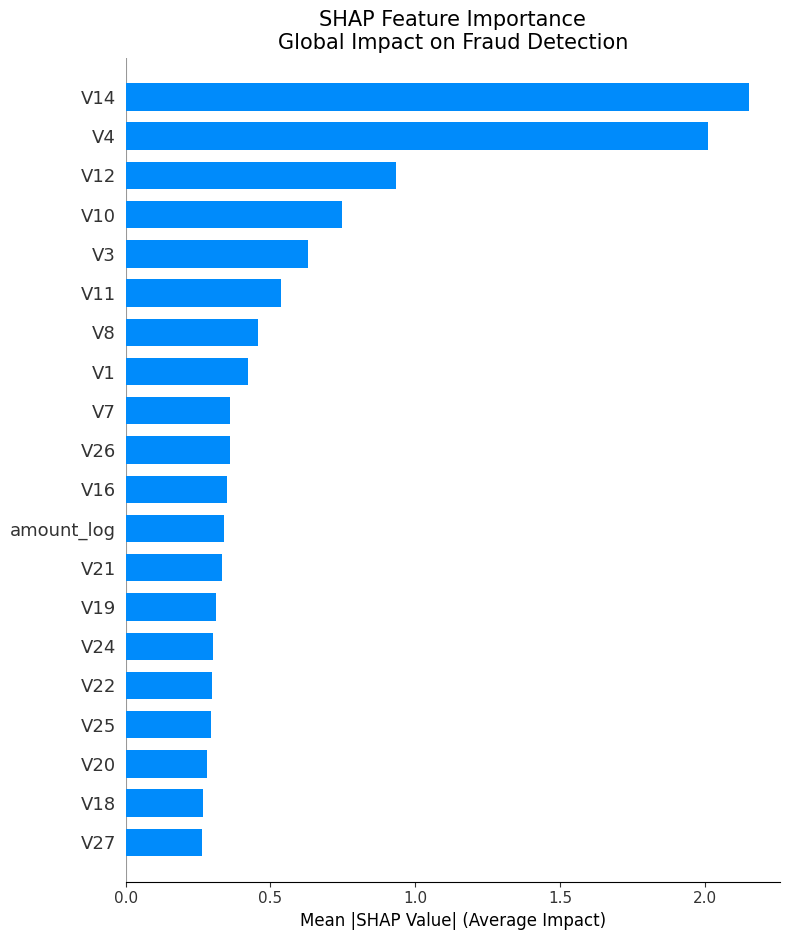

✅ Bar summary plot saved!

Top features = most important for fraud detection
This should confirm V14, V17 from our EDA!


In [9]:
# Cell 5 — SHAP Summary Plot
# This is the MOST important SHAP plot
# Shows which features matter most GLOBALLY

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",      # bar chart style
    max_display=20,       # show top 20 features
    show=False
)

plt.title('SHAP Feature Importance\n'
          'Global Impact on Fraud Detection',
          fontsize=15)
plt.xlabel('Mean |SHAP Value| (Average Impact)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_feature_importance_bar.png',
            bbox_inches='tight')
plt.show()

print("✅ Bar summary plot saved!")
print("\nTop features = most important for fraud detection")
print("This should confirm V14, V17 from our EDA!")

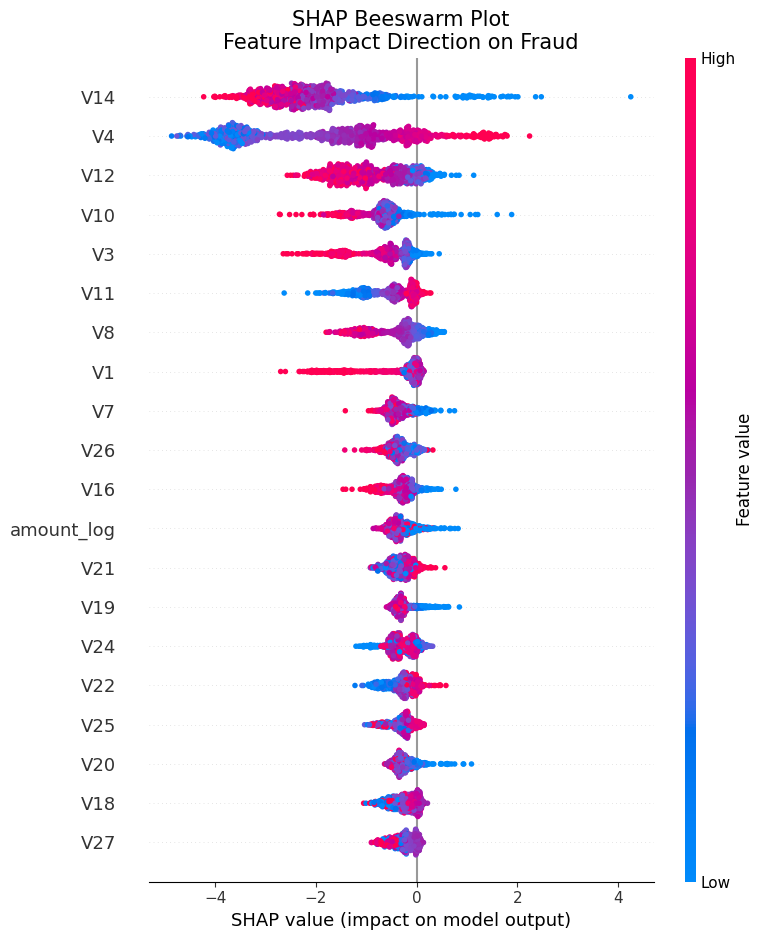


✅ Beeswarm plot saved!

How to read this plot:
──────────────────────────────────────────
X axis = SHAP value
  Right side (+) = pushes toward FRAUD
  Left side  (-) = pushes toward LEGIT

Color = feature value
  Red  = HIGH value for that feature
  Blue = LOW value for that feature

Example for V14:
  Blue dots on RIGHT = low V14 → fraud ✅
  Red dots on LEFT   = high V14 → legit ✅
  This matches our EDA finding!



In [10]:
# Cell 6 — SHAP Beeswarm Plot
# More detailed than bar chart
# Shows DIRECTION of impact too
# Red = high feature value
# Blue = low feature value

plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="dot",      # beeswarm style
    max_display=20,
    show=False
)

plt.title('SHAP Beeswarm Plot\n'
          'Feature Impact Direction on Fraud',
          fontsize=15)
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png',
            bbox_inches='tight')
plt.show()

print("""
✅ Beeswarm plot saved!

How to read this plot:
──────────────────────────────────────────
X axis = SHAP value
  Right side (+) = pushes toward FRAUD
  Left side  (-) = pushes toward LEGIT

Color = feature value
  Red  = HIGH value for that feature
  Blue = LOW value for that feature

Example for V14:
  Blue dots on RIGHT = low V14 → fraud ✅
  Red dots on LEFT   = high V14 → legit ✅
  This matches our EDA finding!
""")

<Figure size 1200x600 with 0 Axes>

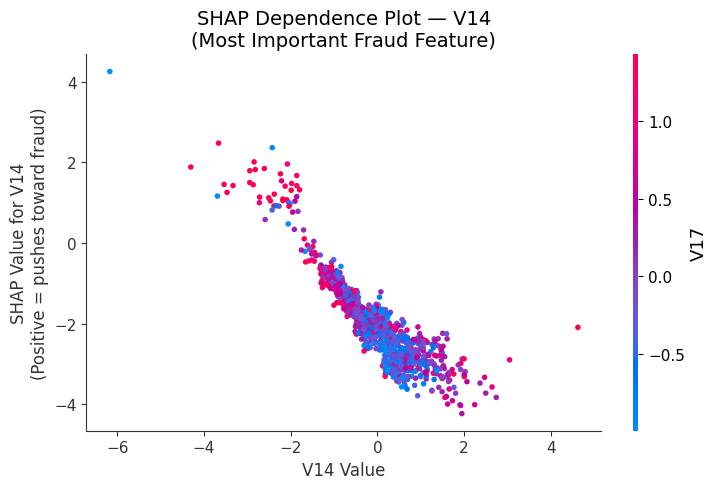


✅ V14 dependence plot saved!

What to look for:
──────────────────────────────────────────
When V14 is very negative (left side):
→ SHAP value is positive = fraud signal
→ Confirms our Day 2 EDA finding! ✅

When V14 is near 0 or positive:
→ SHAP value is negative = legit signal



In [11]:
# Cell 7 — SHAP Dependence Plot for V14
# Shows relationship between V14 value
# and its SHAP impact on fraud probability

plt.figure(figsize=(12, 6))

shap.dependence_plot(
    "V14",
    shap_values,
    X_test_sample,
    interaction_index="V17",  # color by V17
    show=False
)

plt.title('SHAP Dependence Plot — V14\n'
          '(Most Important Fraud Feature)',
          fontsize=14)
plt.xlabel('V14 Value', fontsize=12)
plt.ylabel('SHAP Value for V14\n'
           '(Positive = pushes toward fraud)',
           fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_dependence_V14.png',
            bbox_inches='tight')
plt.show()

print("""
✅ V14 dependence plot saved!

What to look for:
──────────────────────────────────────────
When V14 is very negative (left side):
→ SHAP value is positive = fraud signal
→ Confirms our Day 2 EDA finding! ✅

When V14 is near 0 or positive:
→ SHAP value is negative = legit signal
""")

<Figure size 1200x600 with 0 Axes>

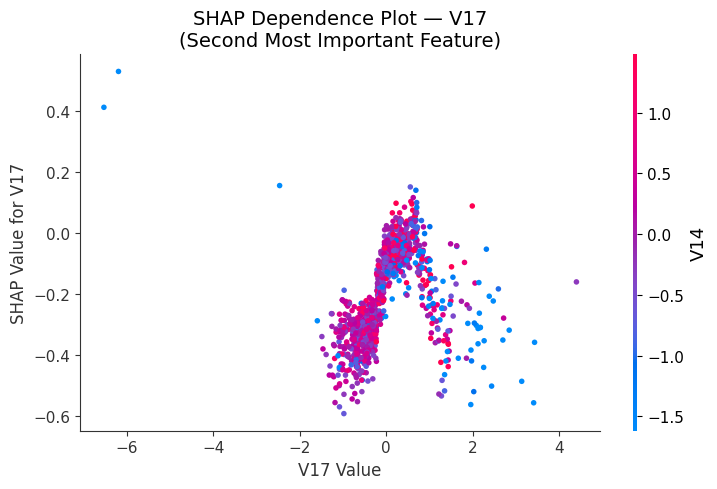

In [12]:
# Cell 8 — Dependence plot for V17
plt.figure(figsize=(12, 6))

shap.dependence_plot(
    "V17",
    shap_values,
    X_test_sample,
    interaction_index="V14",
    show=False
)

plt.title('SHAP Dependence Plot — V17\n'
          '(Second Most Important Feature)',
          fontsize=14)
plt.xlabel('V17 Value', fontsize=12)
plt.ylabel('SHAP Value for V17', fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_dependence_V17.png',
            bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

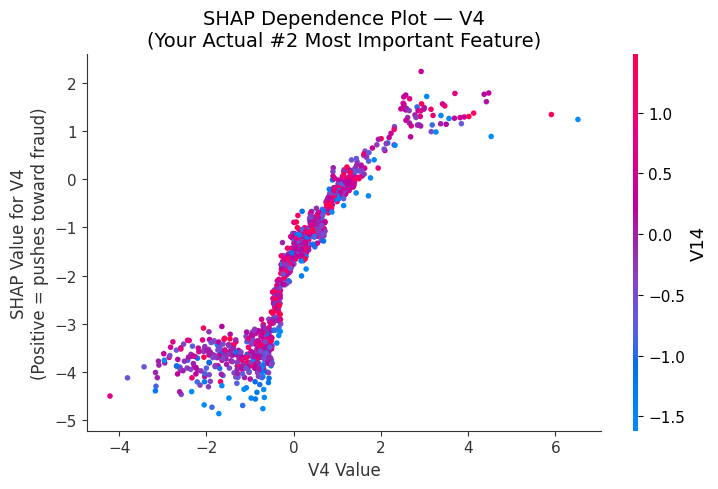

✅ V4 dependence plot saved!

What to look for:
──────────────────────────────────────────
Areas where SHAP value is POSITIVE
→ those V4 values push toward FRAUD

Areas where SHAP value is NEGATIVE
→ those V4 values push toward LEGIT

Color (V14):
Pink/Red  = high V14 value
Blue/Cyan = low V14 value



In [17]:
# Cell 8 — CORRECTED: Dependence plot for V4
# (actual #2 feature from YOUR SHAP results)

plt.figure(figsize=(12, 6))

shap.dependence_plot(
    "V4",              # ← CORRECT! your actual #2
    shap_values,
    X_test_sample,
    interaction_index="V14",  # color by V14 (#1 feature)
    show=False
)

plt.title('SHAP Dependence Plot — V4\n'
          '(Your Actual #2 Most Important Feature)',
          fontsize=14)
plt.xlabel('V4 Value', fontsize=12)
plt.ylabel('SHAP Value for V4\n'
           '(Positive = pushes toward fraud)',
           fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_dependence_V4.png',
            bbox_inches='tight')
plt.show()

print("✅ V4 dependence plot saved!")
print("""
What to look for:
──────────────────────────────────────────
Areas where SHAP value is POSITIVE
→ those V4 values push toward FRAUD

Areas where SHAP value is NEGATIVE
→ those V4 values push toward LEGIT

Color (V14):
Pink/Red  = high V14 value
Blue/Cyan = low V14 value
""")

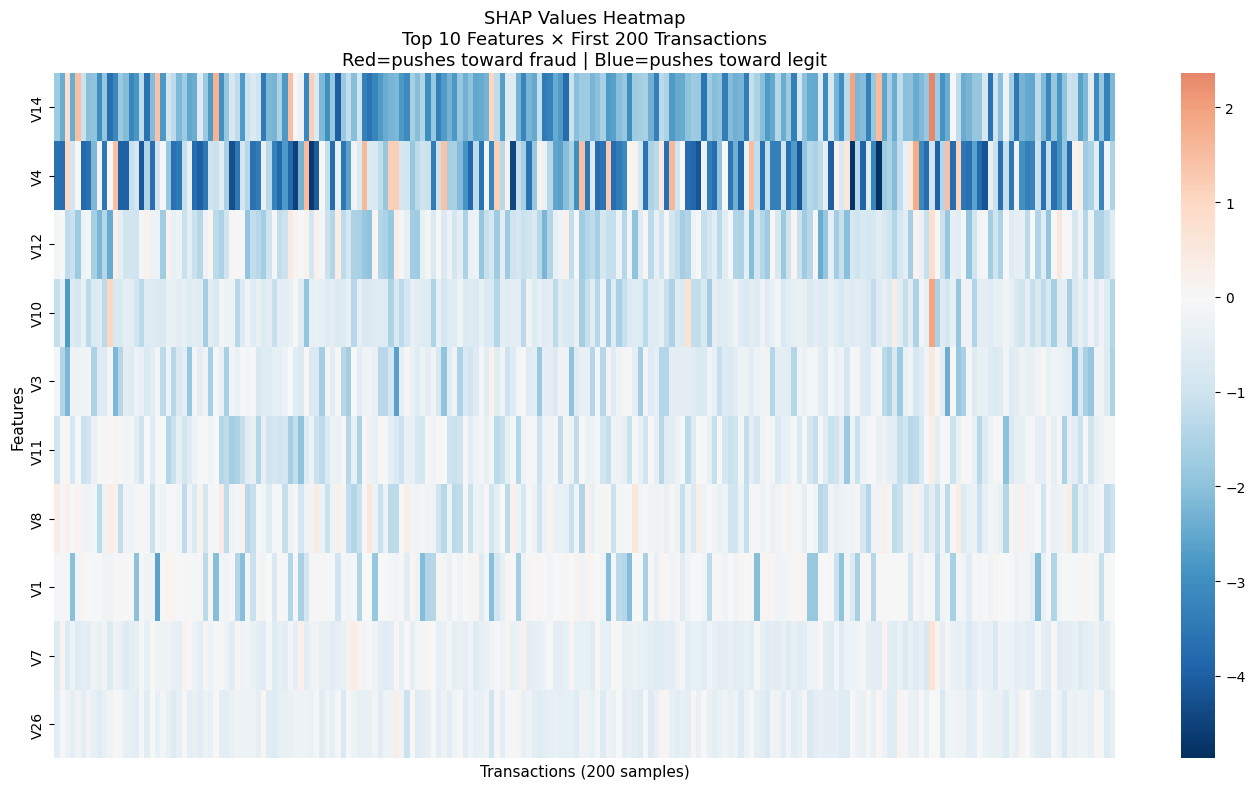

✅ SHAP heatmap saved!

Red columns = transactions model is sure are fraud
Blue columns = transactions model is sure are legit


In [13]:
# Cell 9 — SHAP Heatmap
# Shows SHAP values across all samples
# for top features

# Get top 10 features by importance
feature_importance = np.abs(shap_values).mean(axis=0)
top10_idx = np.argsort(feature_importance)[-10:][::-1]
top10_features = X_test_sample.columns[top10_idx]

# Create heatmap data
shap_top10 = shap_values[:200, top10_idx]  # first 200 samples

plt.figure(figsize=(14, 8))
sns.heatmap(
    shap_top10.T,
    cmap='RdBu_r',
    center=0,
    xticklabels=False,
    yticklabels=top10_features,
    linewidths=0
)
plt.title('SHAP Values Heatmap\n'
          'Top 10 Features × First 200 Transactions\n'
          'Red=pushes toward fraud | Blue=pushes toward legit',
          fontsize=13)
plt.xlabel('Transactions (200 samples)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.tight_layout()
plt.savefig('../data/shap_heatmap.png',
            bbox_inches='tight')
plt.show()

print("✅ SHAP heatmap saved!")
print("\nRed columns = transactions model is sure are fraud")
print("Blue columns = transactions model is sure are legit")

In [14]:
# Cell 10 — Compare SHAP vs EDA findings
feature_importance_df = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print("=== TOP 15 FEATURES BY SHAP ===\n")
print(feature_importance_df.head(15).to_string(index=False))

print("\n=== SHAP vs EDA VERIFICATION ===")
print(f"\nTop 3 from EDA (Day 2-3): V14, V17, V12")
print(f"Top 3 from SHAP:          ", end="")
print(", ".join(feature_importance_df.head(3)['Feature'].tolist()))

top3_shap = feature_importance_df.head(3)['Feature'].tolist()
if 'V14' in top3_shap and 'V17' in top3_shap:
    print("\n✅ SHAP confirms EDA findings!")
    print("V14 and V17 are indeed the strongest fraud indicators")
else:
    print("\n🔍 Interesting! SHAP found different top features")
    print("Model learned different patterns than correlation showed")

=== TOP 15 FEATURES BY SHAP ===

   Feature  Mean_SHAP
       V14   2.152151
        V4   2.011218
       V12   0.934554
       V10   0.746127
        V3   0.628734
       V11   0.534723
        V8   0.455389
        V1   0.421830
        V7   0.360383
       V26   0.359721
       V16   0.349843
amount_log   0.340977
       V21   0.332320
       V19   0.310253
       V24   0.299955

=== SHAP vs EDA VERIFICATION ===

Top 3 from EDA (Day 2-3): V14, V17, V12
Top 3 from SHAP:          V14, V4, V12

🔍 Interesting! SHAP found different top features
Model learned different patterns than correlation showed


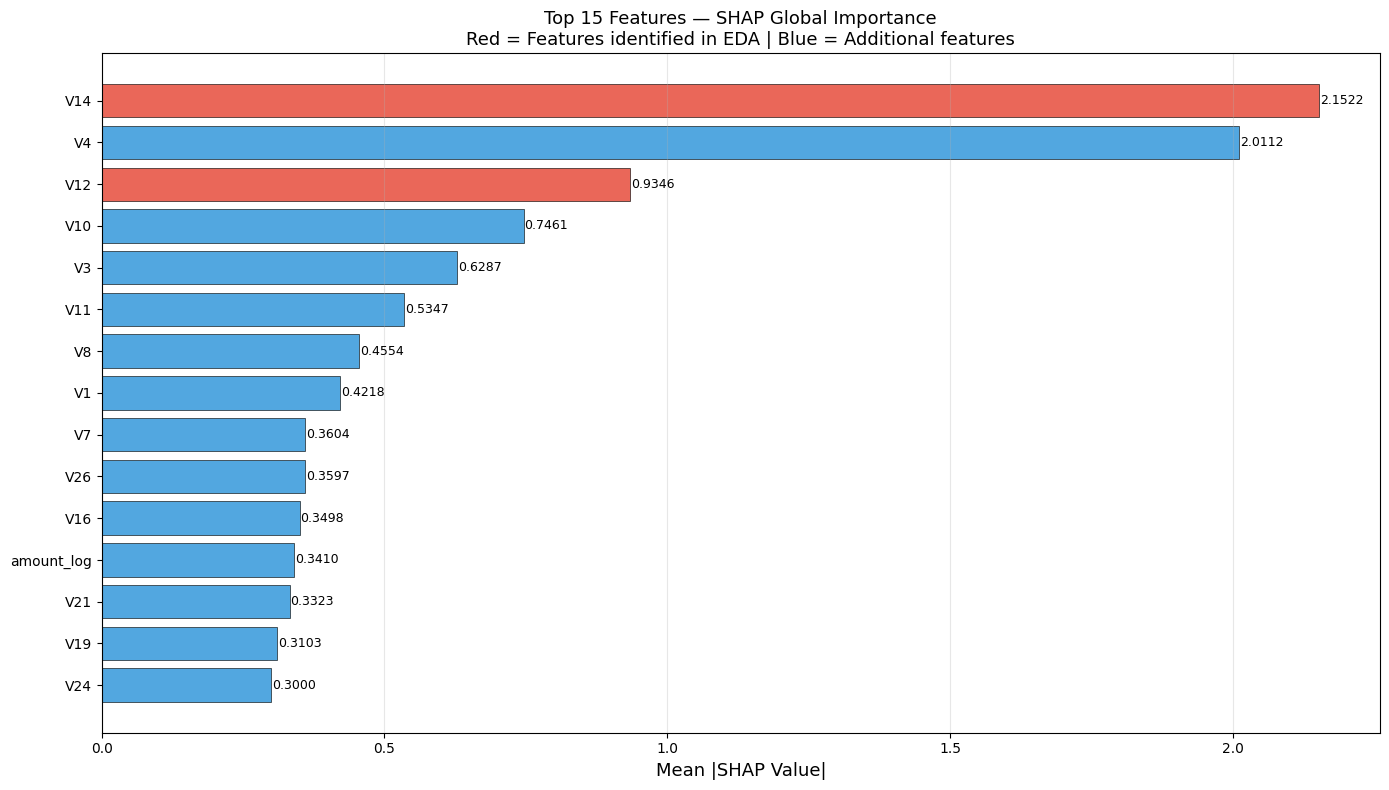

In [15]:
# Cell 11 — Beautiful feature importance plot
plt.figure(figsize=(14, 8))

top15 = feature_importance_df.head(15)
colors = ['#e74c3c' if f in ['V14', 'V17', 'V12']
          else '#3498db'
          for f in top15['Feature']]

bars = plt.barh(
    top15['Feature'][::-1],
    top15['Mean_SHAP'][::-1],
    color=colors[::-1],
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

plt.xlabel('Mean |SHAP Value|', fontsize=13)
plt.title('Top 15 Features — SHAP Global Importance\n'
          'Red = Features identified in EDA | '
          'Blue = Additional features',
          fontsize=13)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars,
                    top15['Mean_SHAP'][::-1]):
    plt.text(val + 0.001, bar.get_y() +
             bar.get_height()/2,
             f'{val:.4f}',
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/shap_top15_features.png',
            bbox_inches='tight')
plt.show()

In [16]:
# Cell 12 — Save SHAP values and explainer
import os
os.makedirs('../models', exist_ok=True)

# Save explainer
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Save SHAP values for sample
np.save('../models/shap_values_sample.npy', shap_values)

# Save feature importance
feature_importance_df.to_csv(
    '../data/shap_feature_importance.csv',
    index=False
)

print("✅ SHAP explainer saved!")
print("✅ SHAP values saved!")
print("✅ Feature importance CSV saved!")
print("\nThese will be used in:")
print("→ Day 12: Individual transaction explanation")
print("→ Day 15: FastAPI — explain each prediction")
print("→ Day 19: Streamlit dashboard SHAP plots")

✅ SHAP explainer saved!
✅ SHAP values saved!
✅ Feature importance CSV saved!

These will be used in:
→ Day 12: Individual transaction explanation
→ Day 15: FastAPI — explain each prediction
→ Day 19: Streamlit dashboard SHAP plots
